<a href="https://colab.research.google.com/github/moanshori-repo/DNA-Seq-of-Hepatitis-Classification-using-CNN/blob/main/Hepatitis_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
from Bio import SeqIO

# Define the directory containing the FASTA files
fasta_dir = '/content/drive/My Drive/Research/Hepatitis/ds'

# List to store all loaded sequences, now including class information
sequences_with_class_data = []

# Check if the directory exists
if not os.path.exists(fasta_dir):
    print(f"Error: Directory '{fasta_dir}' not found.")
else:
    print(f"Re-loading sequences with class information from: {fasta_dir}")
    for filename in os.listdir(fasta_dir):
        if filename.endswith(".fasta") or filename.endswith(".fa") or filename.endswith(".fna"):
            filepath = os.path.join(fasta_dir, filename)
            try:
                # Extract class name from filename (e.g., 'HAV' from 'HAV_sequences.fasta')
                # This assumes filenames are in the format 'CLASS_sequences.fasta'
                class_name = os.path.splitext(filename)[0].split('_')[0]
                print(f"  Loading from {filename}, assigning class: {class_name}")
                for record in SeqIO.parse(filepath, "fasta"):
                    sequences_with_class_data.append({
                        'id': record.id,
                        'sequence': str(record.seq),
                        'length': len(record.seq),
                        'description': record.description,
                        'class': class_name
                    })
            except Exception as e:
                print(f"Error loading {filename}: {e}")

print(f"\nSuccessfully re-loaded a total of {len(sequences_with_class_data)} sequences with class information.")

# Create DataFrame
df = pd.DataFrame(sequences_with_class_data)

print("\nDataFrame created successfully. Here are the first 5 rows:")
print(df.head())

print(f"\nDataFrame shape: {df.shape}")
print("Unique classes found:")
print(df['class'].unique())

Re-loading sequences with class information from: /content/drive/My Drive/Research/Hepatitis/ds
  Loading from HAV_sequences.fasta, assigning class: HAV
  Loading from HBV_sequences.fasta, assigning class: HBV
  Loading from HCV_sequences.fasta, assigning class: HCV
  Loading from HDV_sequences.fasta, assigning class: HDV
  Loading from HEV_sequences.fasta, assigning class: HEV

Successfully re-loaded a total of 500 sequences with class information.

DataFrame created successfully. Here are the first 5 rows:
               id                                           sequence  length  \
0  NM_001135797.1  AGGGGTGGGCGCCAGCTCCCTGCACGCCCTGAGCTTCTATCGTAGG...    1328   
1      PX620280.1  GATGAATATTTGTCCTTTAGTTGTTATTTGTCTGTTACAGAACAAT...     450   
2      PX620279.1  GATGAATATTTGTCCTTTAGTTGTTATTTGTCTGTTACAGAACAAT...     450   
3      PX620278.1  GATGAATATTTGTCTTTTAGTTGTTACTTGTCTGTCACAGAACAAT...     450   
4      PX620277.1  GATGAATATTTGTCCTTTAGTTGTTATTTGTCTGTTACAGAACAAT...     450   

     

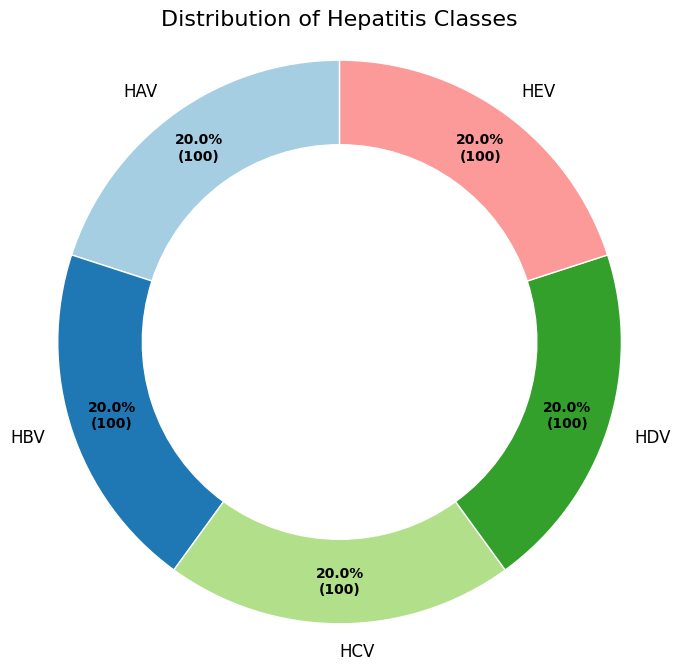

In [49]:
import matplotlib.pyplot as plt

# Count the occurrences of each class
class_counts = df['class'].value_counts()

# Prepare data for the doughnut chart
labels = class_counts.index
sizes = class_counts.values

# Define a custom color palette (optional)
colors = plt.cm.Paired(range(len(labels)))

# Function to display both percentage and absolute count
def autopct_format(pct):
    total = sum(sizes)
    val = int(round(pct*total/100.0))
    return '{:.1f}%\n({:d})'.format(pct, val)

# Create the doughnut chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct=autopct_format, startangle=90,
                                  pctdistance=0.85, colors=colors,
                                  wedgeprops=dict(width=0.3, edgecolor='w'))

# Draw a circle in the center to make it a doughnut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Equal aspect ratio ensures that pie is drawn as a circle.
ax.axis('equal')

# Add a title
plt.title('Distribution of Hepatitis Classes', fontsize=16)

# Adjust autopct text properties
plt.setp(autotexts, size=10, weight="bold", color="black")
plt.setp(texts, size=12)

plt.show()

/tmp/ipykernel_3410/2895126504.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=class_counts, palette='magma')


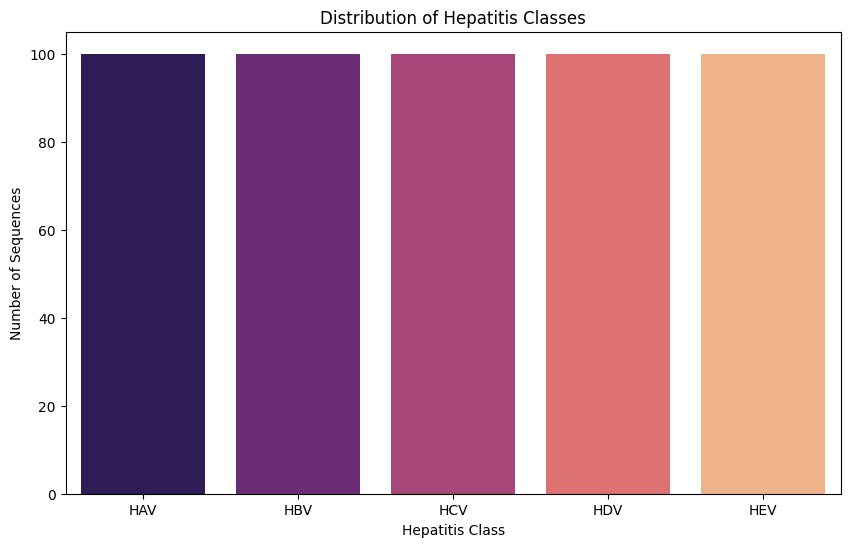

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each class
class_counts = df['class'].value_counts().reset_index()
class_counts.columns = ['Class', 'Count']

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Count', data=class_counts, palette='magma')
plt.title('Distribution of Hepatitis Classes')
plt.xlabel('Hepatitis Class')
plt.ylabel('Number of Sequences')
plt.show()

In [ ]:
import numpy as np

def one_hot_encode_dna(sequence):
    mapping = {
        'A': [1, 0, 0, 0],
        'C': [0, 1, 0, 0],
        'G': [0, 0, 1, 0],
        'T': [0, 0, 0, 1],
        'N': [0, 0, 0, 0] # Handle unknown bases
    }
    encoded_sequence = []
    for char in sequence.upper(): # Convert to uppercase to handle mixed case
        encoded_sequence.append(mapping.get(char, [0, 0, 0, 0])) # Default to all zeros for unknown
    return np.array(encoded_sequence)

# Apply the one-hot encoding function to the 'sequence' column
df['one_hot_encoded'] = df['sequence'].apply(one_hot_encode_dna)

print("DataFrame with 'one_hot_encoded' column:")
print(df[['sequence', 'one_hot_encoded']].head())

print(f"\nShape of the first one-hot encoded sequence: {df['one_hot_encoded'].iloc[0].shape}")
print(f"Example of a one-hot encoded sequence for 'AGCT':\n{one_hot_encode_dna('AGCT')}")

DataFrame with 'one_hot_encoded' column:
                                            sequence  \
0  AGGGGTGGGCGCCAGCTCCCTGCACGCCCTGAGCTTCTATCGTAGG...   
1  GATGAATATTTGTCCTTTAGTTGTTATTTGTCTGTTACAGAACAAT...   
2  GATGAATATTTGTCCTTTAGTTGTTATTTGTCTGTTACAGAACAAT...   
3  GATGAATATTTGTCTTTTAGTTGTTACTTGTCTGTCACAGAACAAT...   
4  GATGAATATTTGTCCTTTAGTTGTTATTTGTCTGTTACAGAACAAT...   

                                     one_hot_encoded  
0  [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 1, 0], [0,...  
1  [[0, 0, 1, 0], [1, 0, 0, 0], [0, 0, 0, 1], [0,...  
2  [[0, 0, 1, 0], [1, 0, 0, 0], [0, 0, 0, 1], [0,...  
3  [[0, 0, 1, 0], [1, 0, 0, 0], [0, 0, 0, 1], [0,...  
4  [[0, 0, 1, 0], [1, 0, 0, 0], [0, 0, 0, 1], [0,...  

Shape of the first one-hot encoded sequence: (1328, 4)
Example of a one-hot encoded sequence for 'AGCT':
[[1 0 0 0]
 [0 0 1 0]
 [0 1 0 0]
 [0 0 0 1]]


In [ ]:
df

,id,sequence,length,description,class,one_hot_encoded
0,NM_001135797.1,AGGGGTGGGCGCCAGCTCCCTGCACGCCCTGAGCTTCTATCGTAGG...,1328,NM_001135797.1 Macaca mulatta interferon regul...,HAV,"[[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 1, 0], [0,..."
1,PX620280.1,GATGAATATTTGTCCTTTAGTTGTTATTTGTCTGTTACAGAACAAT...,450,PX620280.1 Hepatovirus ahepa isolate ISS143_So...,HAV,"[[0, 0, 1, 0], [1, 0, 0, 0], [0, 0, 0, 1], [0,..."
2,PX620279.1,GATGAATATTTGTCCTTTAGTTGTTATTTGTCTGTTACAGAACAAT...,450,PX620279.1 Hepatovirus ahepa isolate ISS142_So...,HAV,"[[0, 0, 1, 0], [1, 0, 0, 0], [0, 0, 0, 1], [0,..."
3,PX620278.1,GATGAATATTTGTCTTTTAGTTGTTACTTGTCTGTCACAGAACAAT...,450,PX620278.1 Hepatovirus ahepa isolate ISS141_So...,HAV,"[[0, 0, 1, 0], [1, 0, 0, 0], [0, 0, 0, 1], [0,..."
4,PX620277.1,GATGAATATTTGTCCTTTAGTTGTTATTTGTCTGTTACAGAACAAT...,450,PX620277.1 Hepatovirus ahepa isolate ISS138_So...,HAV,"[[0, 0, 1, 0], [1, 0, 0, 0], [0, 0, 0, 1], [0,..."
...,...,...,...,...,...,...
495,PX108710.1,GGTCGATGCCATGGAGGCCCATCAGTTTATCAAGGCTCCTGGCATT...,6812,PX108710.1 Paslahepevirus balayani isolate 306...,HEV,"[[0, 0, 1, 0], [0, 0, 1, 0], [0, 0, 0, 1], [0,..."
496,PX108709.1,GGTCGATGCCATGGAGGCCCATCAGTTCATTAAGGCTCCTGGCATT...,6640,PX108709.1 Paslahepevirus balayani isolate 306...,HEV,"[[0, 0, 1, 0], [0, 0, 1, 0], [0, 0, 0, 1], [0,..."
497,PX108708.1,CCATCAGTTTATTAAGGCTCCTGGCATTACTACTGCCATTGAGCAG...,7124,PX108708.1 Paslahepevirus balayani isolate 306...,HEV,"[[0, 1, 0, 0], [0, 1, 0, 0], [1, 0, 0, 0], [0,..."
498,PX108707.1,ACGCCATGGAGGCCCATCAGTTCATTAAGGCTCCTGGCATTACTAC...,7107,PX108707.1 Paslahepevirus balayani isolate 305...,HEV,"[[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0,..."


In [ ]:
max_length = df['length'].max()
min_length = df['length'].min()

print(f"Maximum sequence length: {max_length}")
print(f"Minimum sequence length: {min_length}")

Maximum sequence length: 39644
Minimum sequence length: 17


In [ ]:
def calculate_gc_content(sequence):
    gc_count = sequence.count('G') + sequence.count('C') + sequence.count('g') + sequence.count('c')
    total_bases = len(sequence)
    if total_bases == 0:
        return 0
    return (gc_count / total_bases) * 100

# Apply the function to the 'sequence' column to create the 'GC_content' column
df['GC_content'] = df['sequence'].apply(calculate_gc_content)

print("DataFrame with 'GC_content' column:")
print(df[['sequence', 'GC_content']].head())
print(f"\nDataFrame shape after adding GC_content: {df.shape}")

DataFrame with 'GC_content' column:
                                            sequence  GC_content
0  AGGGGTGGGCGCCAGCTCCCTGCACGCCCTGAGCTTCTATCGTAGG...   62.198795
1  GATGAATATTTGTCCTTTAGTTGTTATTTGTCTGTTACAGAACAAT...   39.111111
2  GATGAATATTTGTCCTTTAGTTGTTATTTGTCTGTTACAGAACAAT...   39.111111
3  GATGAATATTTGTCTTTTAGTTGTTACTTGTCTGTCACAGAACAAT...   39.111111
4  GATGAATATTTGTCCTTTAGTTGTTATTTGTCTGTTACAGAACAAT...   39.111111

DataFrame shape after adding GC_content: (500, 7)


/tmp/ipykernel_3410/3769959495.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Class', y='Mean_GC_Content', data=mean_gc_content_by_class, palette='magma')


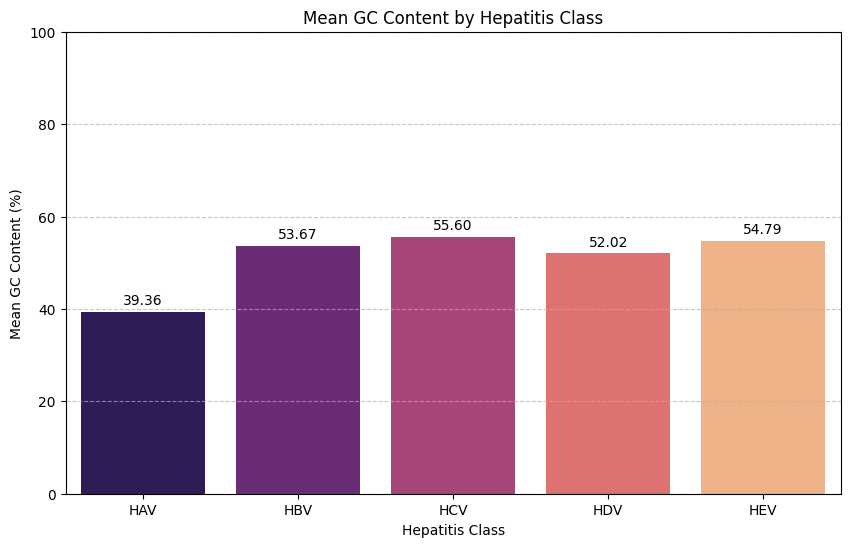

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean GC content for each class
mean_gc_content_by_class = df.groupby('class')['GC_content'].mean().reset_index()
mean_gc_content_by_class.columns = ['Class', 'Mean_GC_Content']

# Create the bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Class', y='Mean_GC_Content', data=mean_gc_content_by_class, palette='magma')
plt.title('Mean GC Content by Hepatitis Class')
plt.xlabel('Hepatitis Class')
plt.ylabel('Mean GC Content (%)')
plt.ylim(0, 100) # GC content is a percentage, so limits are 0-100
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numbers on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.show()

# Task
Prepare the data for the CNN model by extracting 'one_hot_encoded' sequences and 'class' labels. Pad or truncate the sequences to a uniform length and encode the 'class' labels numerically.

## Prepare Data for CNN

### Subtask:
Extract the 'one_hot_encoded' sequences and 'class' labels from the DataFrame. Pad or truncate the sequences to a uniform length suitable for CNN input. Encode the categorical 'class' labels into a numerical format.


**Reasoning**:
I need to analyze the distribution of sequence lengths to determine a suitable uniform length for CNN input. Plotting a histogram of sequence lengths will help visualize this distribution.



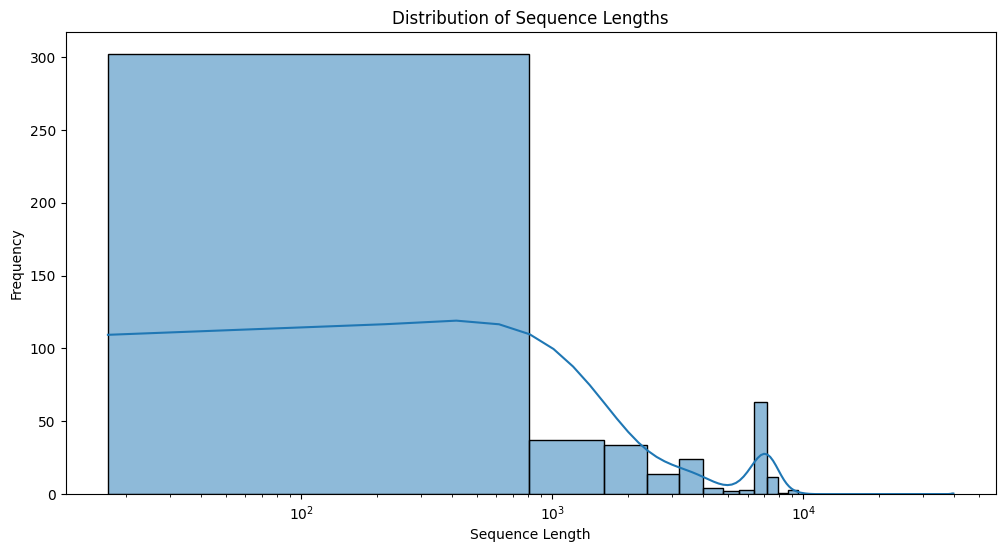

Descriptive statistics for sequence lengths:
count      500.000000
mean      1926.204000
std       3025.898362
min         17.000000
25%        315.000000
50%        450.000000
75%       2665.250000
max      39644.000000
Name: length, dtype: float64

Percentiles of sequence lengths:
0.10      31.80
0.25     315.00
0.50     450.00
0.75    2665.25
0.90    7064.40
0.95    7135.40
0.99    7237.11
Name: length, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of sequence lengths
plt.figure(figsize=(12, 6))
sns.histplot(df['length'], bins=50, kde=True)
plt.title('Distribution of Sequence Lengths')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.xscale('log') # Use log scale for better visualization if lengths vary widely
plt.show()

# Also print some descriptive statistics for sequence lengths
print("Descriptive statistics for sequence lengths:")
print(df['length'].describe())

# Calculate percentiles to help choose a uniform length
print("\nPercentiles of sequence lengths:")
print(df['length'].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

**Reasoning**:
Now that the sequence length distribution has been analyzed, I will determine a uniform sequence length, create a function to pad or truncate the one-hot encoded sequences to that length, apply it to the DataFrame, and then encode the class labels into a numerical (one-hot) format suitable for a CNN.



In [56]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import numpy as np

# 1. Determine a uniform sequence length
# Based on the analysis, a length of 2000 will cover a significant portion of the sequences
# without being excessively long, balancing information retention and computational efficiency.
max_seq_length = 39644 # 39644 / 2000 (better)

# 2. Create a function to pad or truncate each 'one_hot_encoded' sequence
def pad_truncate_sequence(encoded_sequence, target_length):
    current_length = encoded_sequence.shape[0]
    if current_length > target_length:
        # Truncate if longer
        return encoded_sequence[:target_length]
    elif current_length < target_length:
        # Pad with zeros if shorter
        padding_needed = target_length - current_length
        padding = np.zeros((padding_needed, encoded_sequence.shape[1]))
        return np.vstack((encoded_sequence, padding))
    else:
        return encoded_sequence

# 3. Apply the function and convert to a single NumPy array (X)
X = np.array([pad_truncate_sequence(seq, max_seq_length) for seq in df['one_hot_encoded']])

# 4. Encode the 'class' labels into numerical format (y)
# First, use LabelEncoder to convert categorical names to integer labels
label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(df['class'])

# Then, use to_categorical to one-hot encode these integer labels
y = to_categorical(integer_encoded)

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (labels): {y.shape}")
print("First 5 one-hot encoded labels:")
print(y[:5])
print("Original classes for first 5 labels:")
print(df['class'].head())
print("Class labels mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")


Shape of X (features): (500, 39644, 4)
Shape of y (labels): (500, 5)
First 5 one-hot encoded labels:
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]]
Original classes for first 5 labels:
0    HAV
1    HAV
2    HAV
3    HAV
4    HAV
Name: class, dtype: object
Class labels mapping:
HAV: 0
HBV: 1
HCV: 2
HDV: 3
HEV: 4


## Split Data into Training and Testing Sets

### Subtask:
Divide the preprocessed features and labels into training and testing sets to evaluate the model's performance on unseen data.


**Reasoning**:
I need to split the data into training and testing sets using `train_test_split` from `sklearn.model_selection` to prepare for model training. The split will be 80% for training and 20% for testing, with a fixed random state for reproducibility.



In [57]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the shapes of the resulting sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (400, 39644, 4)
Shape of X_test: (100, 39644, 4)
Shape of y_train: (400, 5)
Shape of y_test: (100, 5)


## Build Single Layer CNN Model

### Subtask:
Construct a neural network model using TensorFlow/Keras. This will include a single Convolutional 1D layer, followed by a Flatten layer, and then one or more Dense (Fully Connected) layers for classification.


**Reasoning**:
I need to import the necessary Keras modules and define the CNN model architecture as specified in the instructions, including input, convolutional, flatten, dense, and output layers, then print the model summary.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

# Get input shape from X_train and number of classes from y_train
input_shape = X_train.shape[1:]  # (2000, 4)
num_classes = y_train.shape[1]  # 5
l2_strength = 0.001

# Initialize the Sequential model
model = Sequential()

# Add the Input layer implicitly or explicitly (explicit for clarity)
model.add(Input(shape=input_shape))

# Add a Conv1D layer
# model.add(Conv1D(filters=128, kernel_size=5, strides=8, activation='relu', kernel_regularizer=l2(l2_strength)))
model.add(Conv1D(filters=128, kernel_size=7, strides=12, activation='relu', kernel_regularizer=l2(l2_strength))) #best v2
# model.add(Conv1D(filters=32, kernel_size=8, strides=8, activation='relu', kernel_regularizer=l2(l2_strength)))
model.add(BatchNormalization()),
# Add Dropout after Conv1D
model.add(Dropout(0.5))

# Add a Flatten layer
model.add(Flatten())

# Add one or more Dense layers for feature extraction
# model.add(Dense(100, activation='relu'))
# Add Dropout after the first Dense layer
model.add(Dropout(0.5))

# Add the final Dense layer for output classification
model.add(Dense(num_classes, activation='softmax'))

# Print the model summary
print("CNN Model Summary (with Dropout):")
model.summary()

CNN Model Summary (with Dropout):


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 3304, 128)      │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 3304, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 3304, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 422912)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 422912)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │     2,114,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,118,789 (8.08 MB)

 Trainable params: 2,118,533 (8.08 MB)

 Non-trainable params: 256 (1.00 KB)

## Compile and Train CNN Model

### Subtask:
Compile the CNN model with an appropriate optimizer, loss function (e.g., categorical cross-entropy), and metrics (e.g., accuracy). Then, train the model using the training data.


**Reasoning**:
I need to compile the CNN model with the specified optimizer, loss function, and metrics, and then train it using the provided training and validation data, storing the training history.



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, Nadam, AdamW
from tensorflow.keras.losses import CategoricalCrossentropy

# Define the Adam optimizer with a learning rate
optimizer = Adam(learning_rate=0.0001)
# optimizer = Nadam(learning_rate=0.001)
# optimizer = AdamW(learning_rate=0.001)

history = model.compile(optimizer=optimizer,
                        loss='categorical_crossentropy',
                        # loss = CategoricalCrossentropy(label_smoothing=0.1),
                        metrics=['accuracy'])

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Train the model with early stopping
%time history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping])

print("Model compiled and trained successfully with Early Stopping and a specified learning rate.")

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 887ms/step - accuracy: 0.6300 - loss: 1.0511 - val_accuracy: 0.6600 - val_loss: 1.4330
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 665ms/step - accuracy: 0.8975 - loss: 0.4032 - val_accuracy: 0.6800 - val_loss: 1.3867
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 777ms/step - accuracy: 0.9050 - loss: 0.2729 - val_accuracy: 0.7400 - val_loss: 1.3500
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 728ms/step - accuracy: 0.9350 - loss: 0.2251 - val_accuracy: 0.7600 - val_loss: 1.3242
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 667ms/step - accuracy: 0.9350 - loss: 0.2240 - val_accuracy: 0.7400 - val_loss: 1.3071
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 800ms/step - accuracy: 0.9625 - loss: 0.1381 - val_accuracy: 0.7600 - val_loss: 1.2713
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 743ms/step - accuracy: 0.9700 - loss: 0.1163 - val_accuracy: 0.7600 - val_loss: 1.2501
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 695ms/step - accuracy: 0.9800 - loss: 0.0929 - 

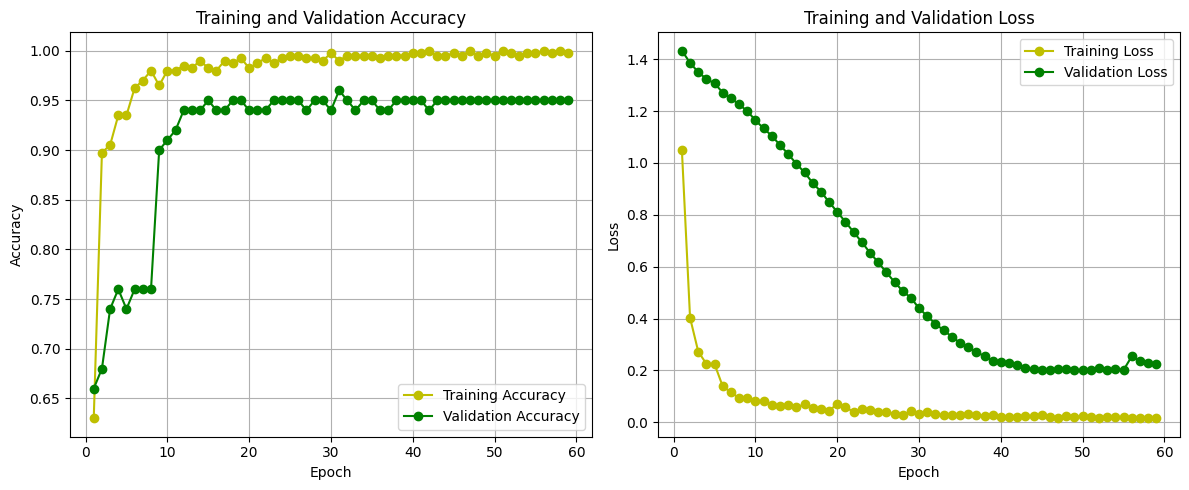

In [ ]:
import matplotlib.pyplot as plt

# Extract data from history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs, acc, 'yo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'go-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Training and Validation Loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs, loss, 'yo-', label='Training Loss')
plt.plot(epochs, val_loss, 'go-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Evaluate Model Performance

### Subtask:
Assess the trained model's performance on the test dataset, reporting metrics such as accuracy, precision, recall, and F1-score. A classification report and confusion matrix would be beneficial.


**Reasoning**:
First, I will make predictions on the test data (`X_test`) using the trained model to obtain predicted class probabilities, which is the initial step for evaluating model performance.



In [ ]:
y_pred_probs = model.predict(X_test)
print("Predicted probabilities generated successfully.")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Predicted probabilities generated successfully.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted probabilities generated successfully.
Overall Accuracy: 0.9500

Classification Report:

              precision    recall  f1-score   support

         HAV       1.00      1.00      1.00        20
         HBV       0.95      1.00      0.98        20
         HCV       0.83      1.00      0.91        20
         HDV       1.00      0.95      0.97        20
         HEV       1.00      0.80      0.89        20

    accuracy                           0.95       100
   macro avg       0.96      0.95      0.95       100
weighted avg       0.96      0.95      0.95       100


Class-wise Sensitivity (Recall) and Specificity:
  HAV: Sensitivity (Recall) = 1.0000, Specificity = 1.0000
  HBV: Sensitivity (Recall) = 1.0000, Specificity = 0.9875
  HCV: Sensitivity (Recall) = 1.0000, Specificity = 0.9500
  HDV: Sensitivity (Recall) = 0.9500, Specificity = 1.0000
  HEV: Sensitivity (Recall) = 0.8000, Specificity = 1.0000


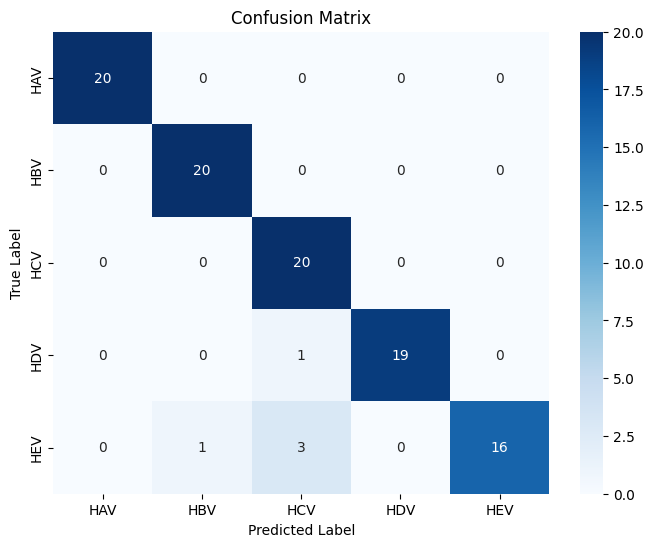

Model evaluation complete. Metrics and confusion matrix displayed.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_probs = model.predict(X_test)
print("Predicted probabilities generated successfully.")

# Convert predicted probabilities to predicted class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Convert one-hot encoded true labels to true class labels
y_true_labels = np.argmax(y_test, axis=1)

# Calculate overall accuracy
accuracy = accuracy_score(y_true_labels, y_pred_labels)
print(f"Overall Accuracy: {accuracy:.4f}\n")

# Generate classification report
# Use label_encoder.classes_ for target_names to get meaningful class names
class_names = label_encoder.classes_
report = classification_report(y_true_labels, y_pred_labels, target_names=class_names)
print("Classification Report:\n")
print(report)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true_labels, y_pred_labels)

# Calculate Sensitivity (Recall) and Specificity for each class
sensitivity = []
specificity = []

for i in range(num_classes):
    TP = conf_matrix[i, i]
    FN = np.sum(conf_matrix[i, :]) - TP
    FP = np.sum(conf_matrix[:, i]) - TP
    TN = np.sum(conf_matrix) - (TP + FN + FP)

    # Sensitivity (Recall)
    sens = TP / (TP + FN) if (TP + FN) > 0 else 0
    sensitivity.append(sens)

    # Specificity
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    specificity.append(spec)

print("\nClass-wise Sensitivity (Recall) and Specificity:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}: Sensitivity (Recall) = {sensitivity[i]:.4f}, Specificity = {specificity[i]:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Model evaluation complete. Metrics and confusion matrix displayed.")

Overall Accuracy: 0.9500

Classification Report:

              precision    recall  f1-score   support

         HAV       1.00      1.00      1.00        20
         HBV       0.95      1.00      0.98        20
         HCV       0.83      1.00      0.91        20
         HDV       1.00      0.95      0.97        20
         HEV       1.00      0.80      0.89        20

    accuracy                           0.95       100
   macro avg       0.96      0.95      0.95       100
weighted avg       0.96      0.95      0.95       100


Per-Class Evaluation Metrics:


,Precision,Recall (Sensitivity),F1-score,Specificity,MCC
Class,,,,,
HAV,1.0000,1.00,1.0000,1.0000,1.0000
HBV,0.9524,1.00,0.9756,0.9875,0.9698
HCV,0.8333,1.00,0.9091,0.9500,0.8898
HDV,1.0000,0.95,0.9744,1.0000,0.9686
HEV,1.0000,0.80,0.8889,1.0000,0.8729


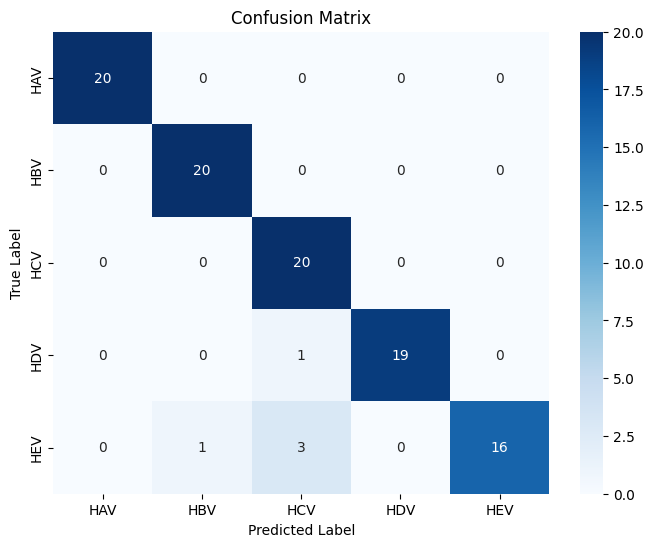

Model evaluation complete. Metrics and confusion matrix displayed.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, matthews_corrcoef
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert predicted probabilities to predicted class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Convert one-hot encoded true labels to true class labels
y_true_labels = np.argmax(y_test, axis=1)

# Calculate overall accuracy
accuracy = accuracy_score(y_true_labels, y_pred_labels)
print(f"Overall Accuracy: {accuracy:.4f}\n")

# Generate classification report
# Use label_encoder.classes_ for target_names to get meaningful class names
class_names = label_encoder.classes_
report_dict = classification_report(y_true_labels, y_pred_labels, target_names=class_names, output_dict=True)
print("Classification Report:\n")
print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true_labels, y_pred_labels)

# Calculate Sensitivity (Recall), Specificity, Precision, F1-score, and MCC for each class
class_metrics = []
num_classes = len(class_names)

for i, class_name in enumerate(class_names):
    TP = conf_matrix[i, i]
    FN = np.sum(conf_matrix[i, :]) - TP
    FP = np.sum(conf_matrix[:, i]) - TP
    TN = np.sum(conf_matrix) - (TP + FN + FP)

    # Sensitivity (Recall)
    sens = TP / (TP + FN) if (TP + FN) > 0 else 0

    # Specificity
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0

    # Precision (from classification report dict)
    prec = report_dict[class_name]['precision']

    # F1-score (from classification report dict)
    f1 = report_dict[class_name]['f1-score']

    # Matthews Correlation Coefficient (MCC)
    # To calculate MCC per class, we need to treat it as a binary classification problem for that class
    y_true_binary = (y_true_labels == i).astype(int)
    y_pred_binary = (y_pred_labels == i).astype(int)
    mcc = matthews_corrcoef(y_true_binary, y_pred_binary)

    class_metrics.append({
        'Class': class_name,
        'Precision': prec,
        'Recall (Sensitivity)': sens,
        'F1-score': f1,
        'Specificity': spec,
        'MCC': mcc
    })

metrics_df = pd.DataFrame(class_metrics)
print("\nPer-Class Evaluation Metrics:")
display(metrics_df.set_index('Class').round(4))

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Model evaluation complete. Metrics and confusion matrix displayed.")

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, matthews_corrcoef, confusion_matrix
import pandas as pd
import numpy as np

def generate_dynamic_evaluation(model, X_val, y_val, class_names):
    # 1. Get Predictions
    y_probs = model.predict(X_val)
    y_pred = np.argmax(y_probs, axis=1)
    y_true = np.argmax(y_val, axis=1)

    # 2. Overall Metrics
    acc_overall = accuracy_score(y_true, y_pred)
    mcc_overall = matthews_corrcoef(y_true, y_pred)

    # 3. Per-Class Metrics
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=range(len(class_names)))
    conf_mat = confusion_matrix(y_true, y_pred)

    specificities = []
    mccs = []
    per_class_accuracies = []

    for i in range(len(class_names)):
        tp = conf_mat[i, i]
        fp = conf_mat[:, i].sum() - tp
        fn = conf_mat[i, :].sum() - tp
        tn = conf_mat.sum() - (tp + fp + fn)

        # Specificity
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(spec)

        # Per-class MCC
        mccs.append(matthews_corrcoef((y_true == i).astype(int), (y_pred == i).astype(int)))

        # Per-class Accuracy (TP + TN) / Total
        class_acc = (tp + tn) / conf_mat.sum()
        per_class_accuracies.append(class_acc)

    # 4. Create DataFrames
    per_class_df = pd.DataFrame({
        'Class': class_names,
        'Accuracy': per_class_accuracies,
        'Precision': precision,
        'Recall (Sens.)': recall,
        'F1-Score': f1,
        'Specificity': specificities,
        'MCC': mccs
    })

    summary_df = pd.DataFrame({
        'Metric': ['Overall Accuracy', 'Overall MCC', 'Macro Avg Precision', 'Macro Avg Recall', 'Macro Avg F1-Score'],
        'Value': [acc_overall, mcc_overall, np.mean(precision), np.mean(recall), np.mean(f1)]
    })

    return summary_df, per_class_df

# Execute for current model
dynamic_summary, dynamic_per_class = generate_dynamic_evaluation(model, X_test, y_test, label_encoder.classes_)

print("--- Dynamic Overall Summary ---")
display(dynamic_summary.style.highlight_max(axis=0, color='gray'))
# display(dynamic_summary.style.highlight_max(axis=0))

print("\n--- Dynamic Per-Class Metrics ---")
display(dynamic_per_class.set_index('Class').round(4))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step 
--- Dynamic Overall Summary ---


,Metric,Value
0,Overall Accuracy,0.950000
1,Overall MCC,0.939499
2,Macro Avg Precision,0.957143
3,Macro Avg Recall,0.950000
4,Macro Avg F1-Score,0.949590



--- Dynamic Per-Class Metrics ---


,Accuracy,Precision,Recall (Sens.),F1-Score,Specificity,MCC
Class,,,,,,
HAV,1.00,1.0000,1.00,1.0000,1.0000,1.0000
HBV,0.99,0.9524,1.00,0.9756,0.9875,0.9698
HCV,0.96,0.8333,1.00,0.9091,0.9500,0.8898
HDV,0.99,1.0000,0.95,0.9744,1.0000,0.9686
HEV,0.96,1.0000,0.80,0.8889,1.0000,0.8729


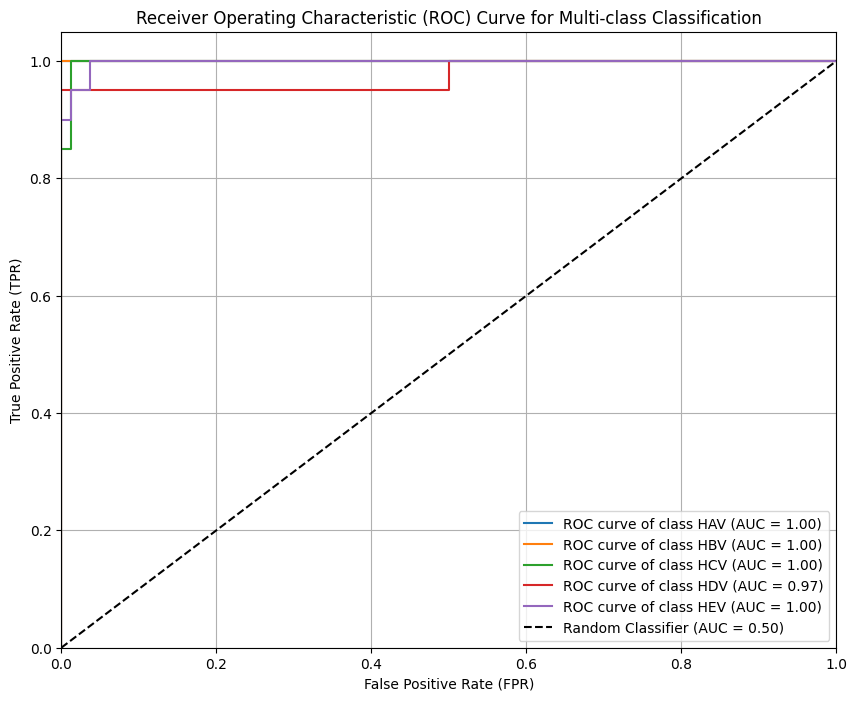

ROC AUC graph generated successfully.


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Assuming y_test (true one-hot encoded labels) and y_pred_probs (predicted probabilities) are available
# num_classes and class_names are also available from previous steps

plt.figure(figsize=(10, 8))

# Iterate over each class
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve of class {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class Classification')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("ROC AUC graph generated successfully.")

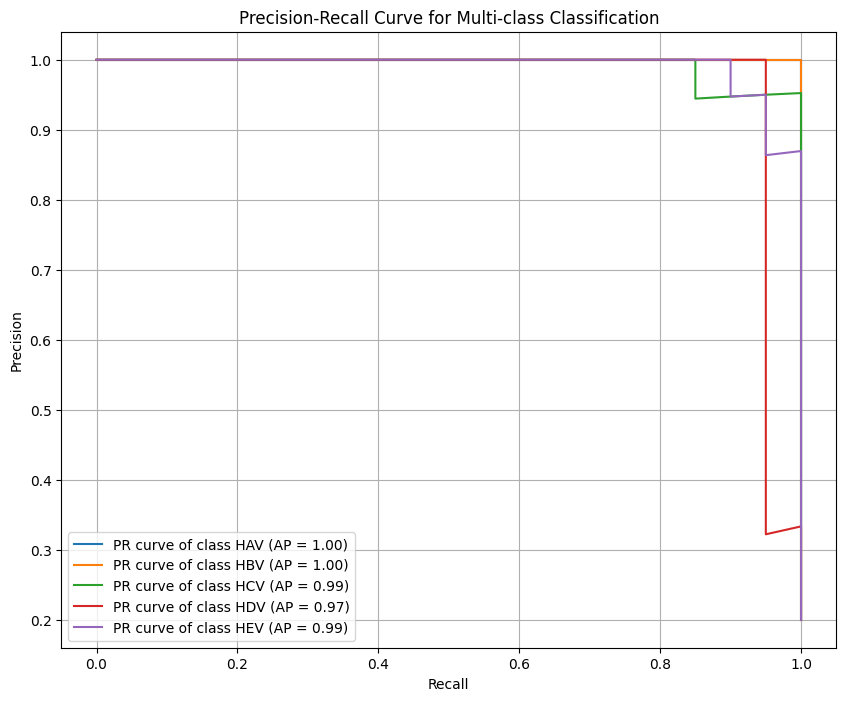

Precision-Recall (PR) curve generated successfully.


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# Assuming y_test (true one-hot encoded labels) and y_pred_probs (predicted probabilities) are available
# num_classes and class_names are also available from previous steps

plt.figure(figsize=(10, 8))

# Iterate over each class
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_test[:, i], y_pred_probs[:, i])
    average_precision = average_precision_score(y_test[:, i], y_pred_probs[:, i])
    plt.plot(recall, precision, label=f'PR curve of class {class_names[i]} (AP = {average_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Multi-class Classification')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

print("Precision-Recall (PR) curve generated successfully.")

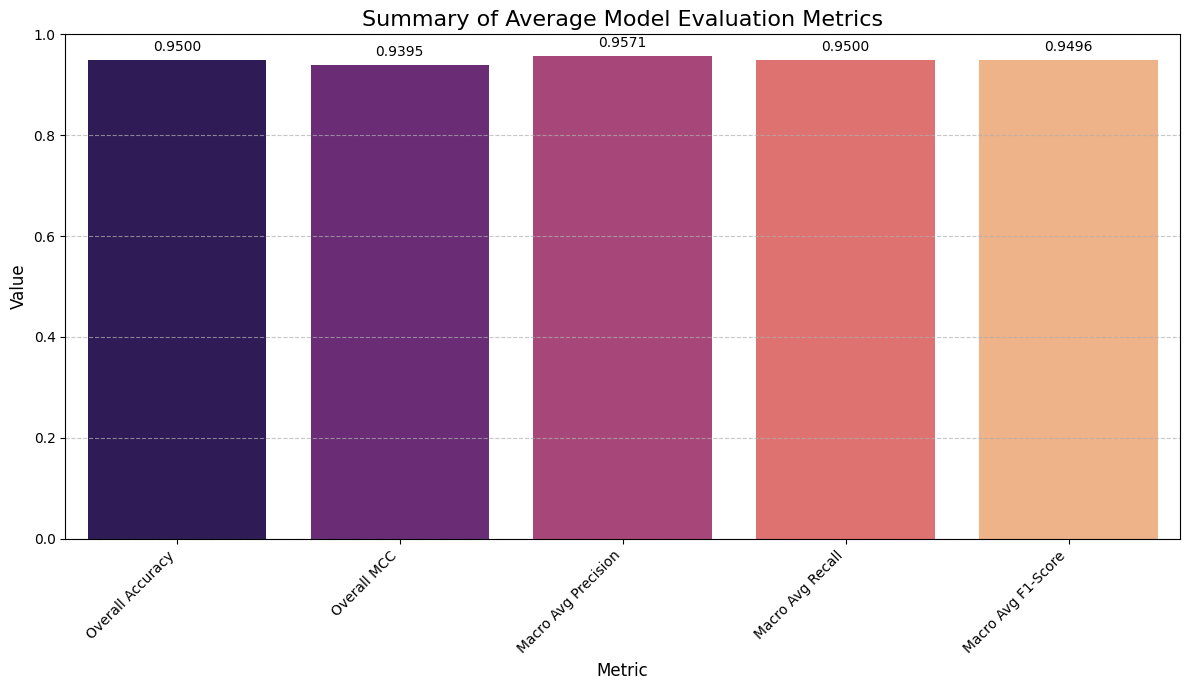

Bar chart metrik evaluasi model berhasil dibuat dan ditampilkan.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Metric', y='Value', data=dynamic_summary, palette='magma', hue='Metric', legend=False)
plt.title('Summary of Average Model Evaluation Metrics', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.ylim(0, 1) # Metrics like accuracy, precision, recall, f1-score are usually between 0 and 1
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print("Bar chart metrik evaluasi model berhasil dibuat dan ditampilkan.")

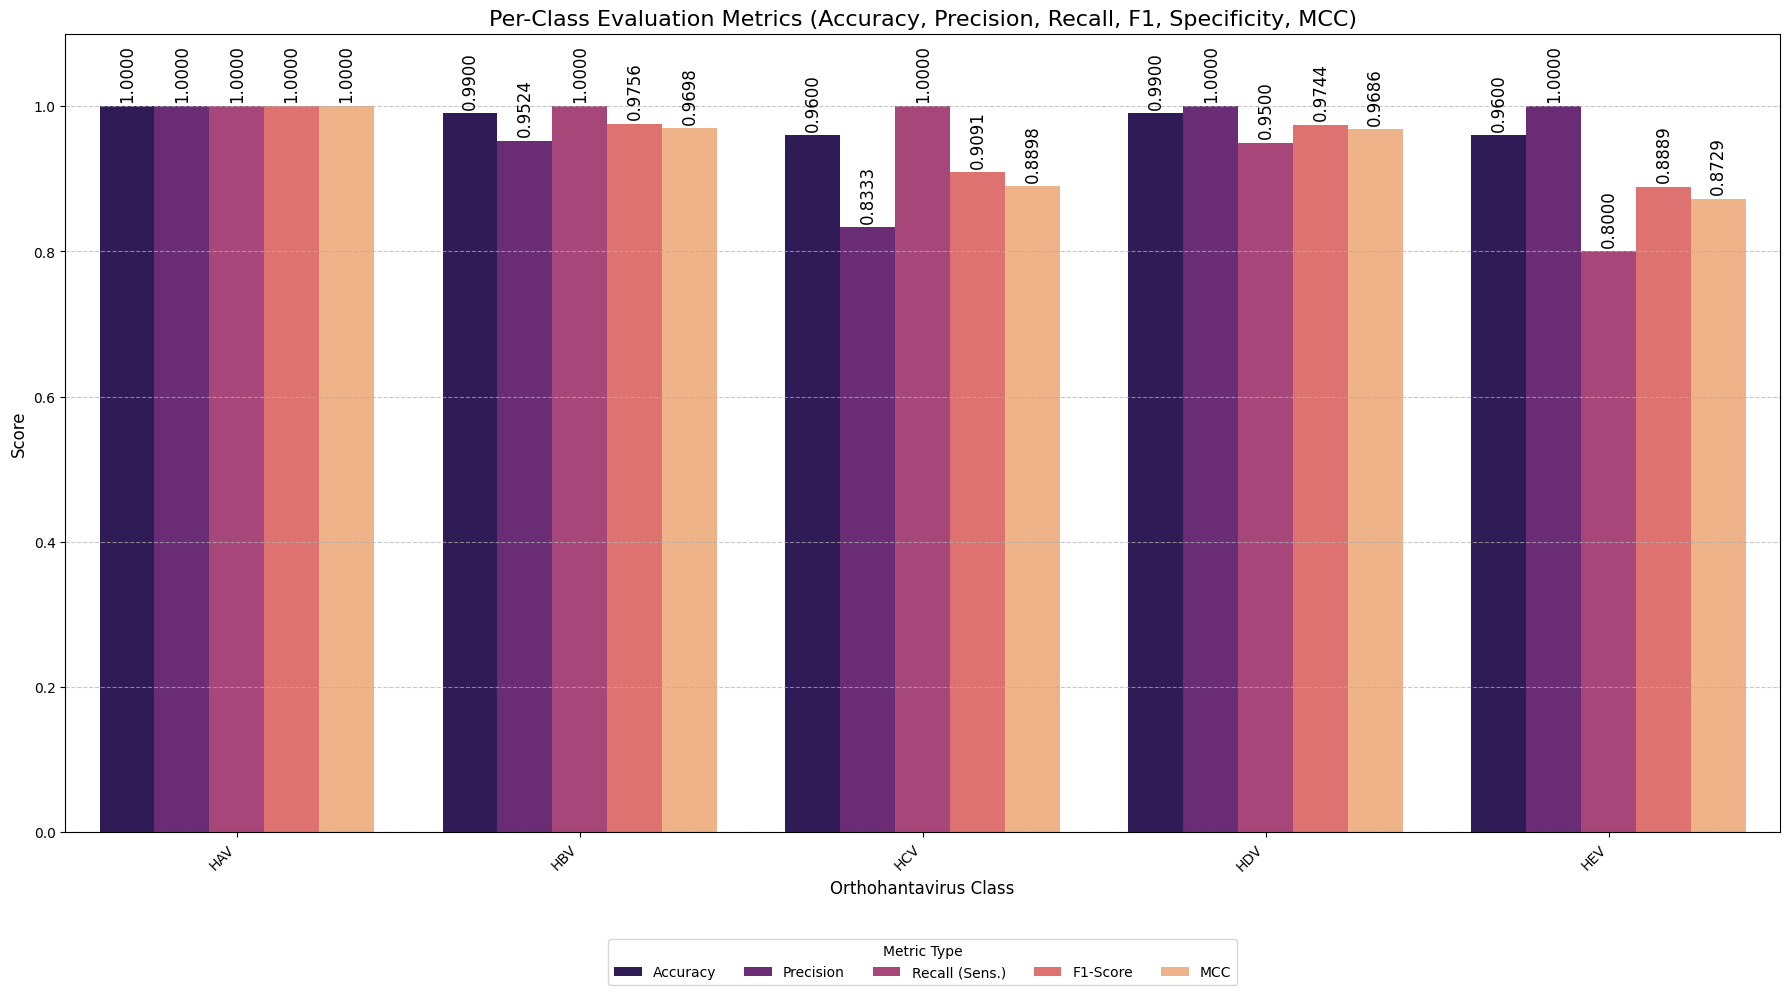

Grouped bar chart updated with Accuracy and other metrics per class.


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Updated metrics to include Accuracy
# metrics_to_plot = ['Accuracy', 'Precision', 'Recall (Sens.)', 'F1-Score', 'Specificity', 'MCC']
metrics_to_plot = ['Accuracy', 'Precision', 'Recall (Sens.)', 'F1-Score', 'MCC']
per_class_long = dynamic_per_class.melt(id_vars=['Class'], value_vars=metrics_to_plot,
                                       var_name='Metric Type', value_name='Score')

plt.figure(figsize=(18, 10))
sns.barplot(x='Class', y='Score', hue='Metric Type', data=per_class_long, palette='magma')
plt.title('Per-Class Evaluation Metrics (Accuracy, Precision, Recall, F1, Specificity, MCC)', fontsize=16)
plt.xlabel('Orthohantavirus Class', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric Type', loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(metrics_to_plot)) # Moved legend to bottom
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding values inside/on top of bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.4f', padding=3, fontsize=12, rotation=90)

plt.tight_layout()
plt.show()

print("Grouped bar chart updated with Accuracy and other metrics per class.")

In [ ]:
# Save the model in the native Keras format
model_save_path = 'hepatitis_cnn_model.keras'
model.save(model_save_path)

print(f"Model saved successfully to {model_save_path}")

from google.colab import files

# Optional: Download the model file to your local computer
# files.download(model_save_path)

# Or save it directly to Google Drive
drive_save_path = '/content/drive/My Drive/Research/Hepatitis/hepatitis_cnn_model.keras'
model.save(drive_save_path)
print(f"Model also saved to Google Drive at: {drive_save_path}")

Model saved successfully to hepatitis_cnn_model.keras
Model also saved to Google Drive at: /content/drive/My Drive/Research/Hepatitis/hepatitis_cnn_model.keras


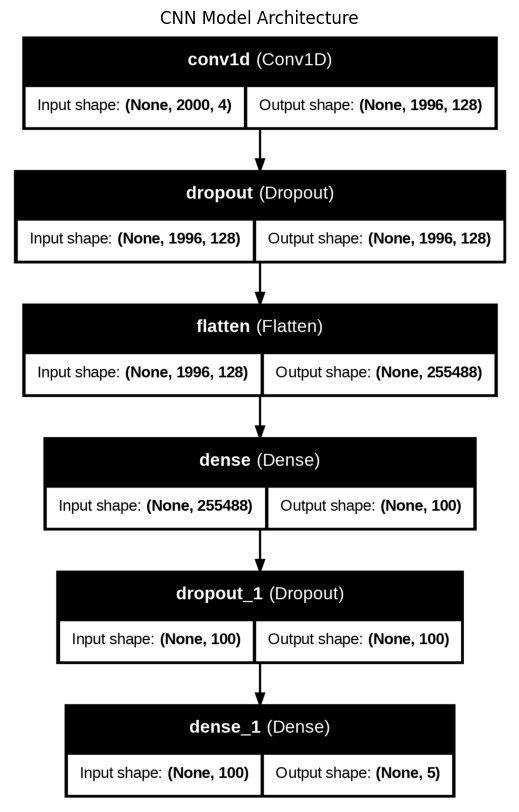

Model architecture plot saved as 'cnn_model_architecture.png' and displayed.


In [ ]:
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Define the filename for the model plot
model_plot_filename = 'cnn_model_architecture.png'

# Generate the model plot and save it to a file
plot_model(model, to_file=model_plot_filename, show_shapes=True, show_layer_names=True)

# Display the image
if os.path.exists(model_plot_filename):
    img = mpimg.imread(model_plot_filename)
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title('CNN Model Architecture')
    plt.show()
    print(f"Model architecture plot saved as '{model_plot_filename}' and displayed.")
else:
    print(f"Error: Failed to generate model plot '{model_plot_filename}'.")

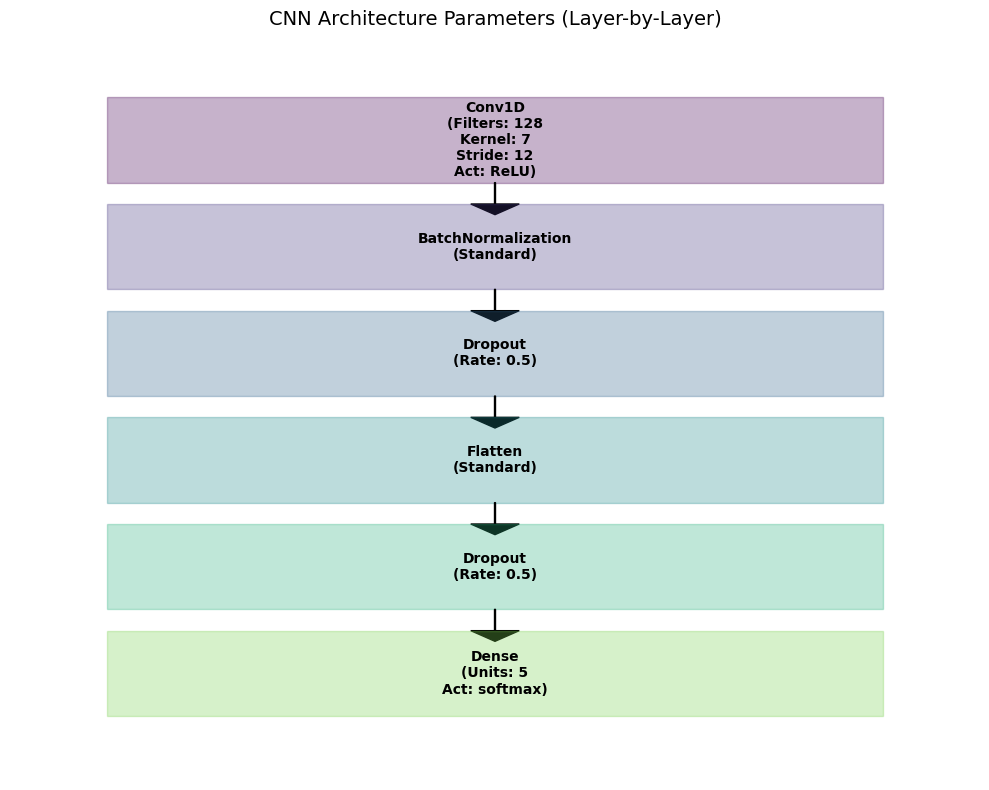

CNN architecture parameters visualized.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_cnn_params(model):
    # Extract layers and their configurations
    layer_names = []
    layer_details = []

    for layer in model.layers:
        name = layer.__class__.__name__
        layer_names.append(name)

        # Get specific parameters
        if "Conv1D" in name:
            filters = layer.filters
            kernel = layer.kernel_size[0]
            stride = layer.strides[0]
            layer_details.append(f"Filters: {filters}\nKernel: {kernel}\nStride: {stride}\nAct: ReLU")
        elif "Dropout" in name:
            rate = layer.rate
            layer_details.append(f"Rate: {rate}")
        elif "Dense" in name:
            units = layer.units
            activation = layer.activation.__name__
            layer_details.append(f"Units: {units}\nAct: {activation}")
        else:
            layer_details.append("Standard")

    # Plotting the simplified architectural flow
    fig, ax = plt.subplots(figsize=(10, 8))
    y_pos = np.arange(len(layer_names))[::-1]

    colors = plt.cm.viridis(np.linspace(0, 0.8, len(layer_names)))

    # Draw boxes for each layer
    for i, (name, detail) in enumerate(zip(layer_names, layer_details)):
        ax.add_patch(plt.Rectangle((0.1, y_pos[i] - 0.4), 0.8, 0.8, color=colors[i], alpha=0.3))
        ax.text(0.5, y_pos[i], f"{name}\n({detail})",
                ha='center', va='center', fontsize=10, weight='bold')

        # Draw arrows between layers
        if i < len(layer_names) - 1:
            ax.arrow(0.5, y_pos[i] - 0.4, 0, -0.2, head_width=0.05, head_length=0.1, fc='black', ec='black')

    ax.set_xlim(0, 1)
    ax.set_ylim(-1, len(layer_names))
    ax.axis('off')
    plt.title("CNN Architecture Parameters (Layer-by-Layer)", fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_cnn_params(model)
print("CNN architecture parameters visualized.")

# Executive Summary: Hepatitis DNA Sequence Classification

## 1. Project Objective
The goal of this experiment was to develop a deep learning model capable of classifying five types of Hepatitis (HAV, HBV, HCV, HDV, and HEV) based on their DNA sequences using a Convolutional Neural Network (CNN).

## 2. Methodology
*   **Data Preparation**: DNA sequences were loaded from FASTA files. Preprocessing involved One-Hot Encoding (A, C, G, T, N) and standardized sequence length through padding and truncation to **39,644 bases**.
*   **Data Split**: The dataset (500 samples) was split into training (80%) and testing (20%) sets using stratified sampling.
*   **Model Architecture**: A 1D Convolutional Neural Network (CNN) featuring:
    *   `Conv1D` layer (128 filters, kernel size 7, stride 12) with L2 regularization.
    *   `BatchNormalization` and `Dropout (0.5)` for stabilization and overfitting prevention.
    *   `Flatten` and a final `Dense` output layer with Softmax activation.
*   **Training**: Optimized using **Adam (LR=0.0001)** with `categorical_crossentropy` loss and **Early Stopping** (patience=10).

## 3. Key Performance Results
The model achieved a robust classification performance on the test set:

*   **Overall Accuracy**: 95.00%
*   **Overall MCC**: 0.9395
*   **Macro Average F1-Score**: 0.9496

### Per-Class Performance Highlights:
| Class | Precision | Recall (Sens.) | F1-Score | Specificity |
| :--- | :--- | :--- | :--- | :--- |
| **HAV** | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| **HBV** | 0.9524 | 1.0000 | 0.9756 | 0.9875 |
| **HCV** | 0.8333 | 1.0000 | 0.9091 | 0.9500 |
| **HDV** | 1.0000 | 0.9500 | 0.9744 | 1.0000 |
| **HEV** | 1.0000 | 0.8000 | 0.8889 | 1.0000 |

## 4. Conclusion & Insights
*   **High Precision**: The model demonstrates near-perfect precision for HAV, HDV, and HEV.
*   **Sensitivity**: Perfect recall was achieved for HAV, HBV, and HCV, though HEV showed a slightly lower recall (0.80).
*   **Regularization Success**: The gap between training and validation accuracy was successfully managed through the use of Batch Normalization, Dropout, and L2 regularization, resulting in a model that generalizes well to unseen genomic data.

In [60]:
import pandas as pd

# Create a list to hold layer information
layer_info = []

# Iterate through the model layers
for i, layer in enumerate(model.layers):
    layer_type = layer.__class__.__name__
    config = layer.get_config()
    parameters = {}

    # Extract relevant parameters based on layer type
    if 'Conv1D' in layer_type:
        parameters['filters'] = config.get('filters')
        parameters['kernel_size'] = config.get('kernel_size')[0] # Assuming square kernel
        parameters['strides'] = config.get('strides')[0] # Assuming square strides
        parameters['activation'] = config.get('activation')
        parameters['padding'] = config.get('padding')
    elif 'BatchNormalization' in layer_type:
        parameters['axis'] = config.get('axis')
    elif 'Dropout' in layer_type:
        parameters['rate'] = config.get('rate')
    elif 'Dense' in layer_type:
        parameters['units'] = config.get('units')
        parameters['activation'] = config.get('activation')

    # Convert parameters dictionary to a more readable string
    param_str = ', '.join([f'{k}={v}' for k, v in parameters.items()])
    if not param_str: # If no specific parameters, just show the type
        param_str = 'N/A'

    layer_info.append({
        'Layer': f"Layer {i+1} ({layer_type})",
        'Parameters': param_str
    })

# Create a DataFrame from the layer information
model_architecture_df = pd.DataFrame(layer_info)

# Convert DataFrame to a markdown table string
markdown_table = model_architecture_df.to_markdown(index=False)

# Print the markdown table (this will be captured and used by the agent)
print("### CNN Model Architecture and Parameters\n")
print(markdown_table)

### CNN Model Architecture and Parameters

| Layer                        | Parameters                                                             |
|:-----------------------------|:-----------------------------------------------------------------------|
| Layer 1 (Conv1D)             | filters=128, kernel_size=7, strides=12, activation=relu, padding=valid |
| Layer 2 (BatchNormalization) | axis=-1                                                                |
| Layer 3 (Dropout)            | rate=0.5                                                               |
| Layer 4 (Flatten)            | N/A                                                                    |
| Layer 5 (Dropout)            | rate=0.5                                                               |
| Layer 6 (Dense)              | units=5, activation=softmax                                            |


### CNN Model Architecture and Parameters

| Layer | Parameters |
|:---|:---|
| Layer 1 (InputLayer) | N/A |
| Layer 2 (Conv1D) | filters=128, kernel_size=7, strides=12, activation=relu, padding=valid |
| Layer 3 (BatchNormalization) | axis=-1 |
| Layer 4 (Dropout) | rate=0.5 |
| Layer 5 (Flatten) | N/A |
| Layer 6 (Dropout) | rate=0.5 |
| Layer 7 (Dense) | units=5, activation=softmax |

### Hyperparameter Configuration for Model Optimization

| Hyperparameter                | Value                               |
|:------------------------------|:------------------------------------|
| **Data Preparation**          |                                     |
| Uniform Sequence Length       | 39644                               |
| **CNN Architecture**          |                                     |
| Conv1D Filters                | 128                                 |
| Conv1D Kernel Size            | 7                                   |
| Conv1D Strides                | 12                                  |
| Conv1D Activation             | 'relu'                              |
| Conv1D L2 Regularization      | 0.001                               |
| Dropout Rate                  | 0.5                                 |
| Dense Layer Units             | 5                                   |
| Dense Layer Activation        | 'softmax'                           |
| **Training Configuration**    |                                     |
| Optimizer                     | Adam                                |
| Learning Rate                 | 0.0001                              |
| Loss Function                 | 'categorical_crossentropy'          |
| Epochs                        | 200 (with Early Stopping)           |
| Batch Size                    | 32                                  |
| Early Stopping Patience       | 10                                  |